# Prediction quality across the predictive-heads campaign

This notebook measures how molecule prediction quality differs across the 8 declared
`predictive_initial` loss conditions (masked/positive-weighted multi-label BCE variants,
a three-state PNU head, a variational PU bound, a symmetric PU ranking loss) and the
`historical_bce` baseline. `part_3` measures the representation directly; this notebook
measures what the classifier does with it, and `part_7` (decision summary, once built)
combines the two.

## Introduction

Unlike the contractive campaign's single fixed head evaluated at a fixed threshold, this
campaign's conditions are genuinely different *objectives* over a shared evidence policy
(positive/negative/unlabelled per pixel per class). Evaluation therefore uses two fixed
populations rather than one class scope:

- **`annotation_retrieval`** — every entry the evidence policy did not mark unavailable
  (positive or negative), the broad population;
- **`operational_pn`** — only entries confidently marked positive or negative (excludes
  the ambiguous/unlabelled middle), the population closest to a clean two-class problem.

Within each population, classes are further split into **scopes**: `train_supported`
(every class with at least one training positive), and `rare`/`medium`/`frequent`
frequency bands. No threshold-dependent metric (macro/micro F1, precision, recall,
Hamming loss) exists here the way it did for the contractive campaign's fixed binary
head — these conditions include a three-state and a ranking-only loss with no shared
notion of a 0.5 decision threshold, so only threshold-free ranking metrics
(`average_precision`, `roc_auc`) and the prevalence-relative `ap_above_prevalence` are
reported.

### Assumptions

- **The compared models share their data and evidence policy.** All `predictive_initial`
  conditions use the same backbone, dataset contract and evidence thresholds
  (`part_0_0` verifies the manifests); only the classification-head loss differs.
  `historical_bce` is a separately trained model, not a repetition of this grid (see
  `part_0_0`'s own assumption on this).
- **A class must be eligible to enter a macro average.** `average_precision`/`roc_auc`
  are undefined for a class with no available positive or no available negative in a
  population; such classes are excluded from every macro mean below (`eligible` in the
  base `per_class` table), not scored as zero.
- **No shared calibration/threshold analysis exists here**, unlike the contractive
  notebook this one is ported from: a PNU head's three-state logits and a ranking-only
  loss's scores are not on a probability scale in the same sense a binary sigmoid's are,
  so no "does the threshold metric track ranking quality" section is included — there is
  no threshold metric to check it against.
- **Five repetitions per condition bound seed noise, not the population.**

### Notation

For condition $c$ and repetition $r$, $\mathrm{AP}_c(r)$ is the macro average precision
over eligible classes in population $p$ and scope $s$. $\mathrm{AP}_c$ denotes its mean
over repetitions. $n^{\mathrm{train}}_k$ is class $k$'s training positive count.

In [1]:
import json
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy.stats import spearmanr

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_campaign as campaign
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_precompute as cache
from msi_autoencoder_wrapper.analysis.autoencoder.experiments import predictive_reports as reports
from msi_autoencoder_wrapper.utils.logger import get_custom_logger
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

logger = get_custom_logger("prediction_global")

2026-09-14 17:41:03,497 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.
2026-09-14 17:41:03,501 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.
2026-09-14 17:41:04,158 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.
2026-09-14 17:41:04,160 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 28 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.
2026-09-14 17:41:04,162 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.
2026-09-14 17

## Configuration

## Producing the tables this notebook reads

### Methodology

#### Implementation

No new precompute routine backs this notebook: `prediction`, `per_class` and
`score_diagnostics` are already written by the base full-campaign inference cache
(`predictive_precompute.precompute`), one row per (model, split, population, scope,
metric). This notebook only derives cheap summaries from tables already on disk.

If those tables are missing, `predictive_precompute.load_table` names the base
precompute command that produces them.

### Remarks

### Notes

In [2]:
SETTINGS_PATH = Path("assets/experiments/autoencoder_architecture/notebooks/14_09_predictive_expanded/analysis_settings.yaml")
NOTEBOOK_DIR = SETTINGS_PATH.parent
RESULTS = NOTEBOOK_DIR / "part_4_prediction_global_results"
RESULTS.mkdir(exist_ok=True)

settings = campaign.load_settings(SETTINGS_PATH)
SAMPLE_SEED = int(settings["sample_seed"])

theme = resolve_theme(None)
theme.apply()

# --- embedded figure resolution --------------------------------------------
FIGURE_RASTER_DPI = 100
plt.rcParams["savefig.dpi"] = FIGURE_RASTER_DPI
# ---------------------------------------------------------------------------

In [3]:
models, _ = campaign.inventory(settings)
ready = models[models.ready]
prediction = cache.load_table(settings, "prediction")
per_class = cache.load_table(settings, "per_class")
score_diagnostics = cache.load_table(settings, "score_diagnostics")

CONDITION_ORDER = reports.condition_order(ready)
LABEL_COLOR = {label: theme.color_for_model(label, index) for index, label in enumerate(CONDITION_ORDER)}
POPULATION = "annotation_retrieval"   # primary population; operational_pn is the secondary, cleaner-label one
SPLIT = "test"

print(f"{ready.model_id.nunique()} ready model(s), {len(prediction)} prediction row(s), "
     f"{len(per_class)} per-class row(s) over {per_class.class_index.nunique()} class(es)")
print(f"populations: {sorted(prediction.population.unique())}, scopes: {sorted(prediction.scope.unique())}")

2026-09-14 17:41:16,486 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_campaign:276 | Audited 120 model manifests across 4 sources.
120 ready model(s), 10800 prediction row(s), 365760 per-class row(s) over 508 class(es)
populations: ['annotation_retrieval', 'operational_pn'], scopes: ['frequent', 'medium', 'rare', 'train_supported']


## Prediction metrics across the campaign

### Methodology

#### Theoretical

`average_precision` and `roc_auc` are threshold-free ranking metrics; `ap_above_prevalence`
is average precision minus the class's own positive prevalence, i.e. how much better than
"guess the base rate" the ranking is — a class with 90% prevalence and 0.91 AP is barely
informative, while the same AP on a 1%-prevalent class is not. All three are reported per
population and scope so a change confined to rare classes or to one evidence population is
visible rather than averaged away.

#### Implementation

Values come directly from the base cache's `prediction` table (already computed by
`heads.predictive_comparison.ranking_tables`); nothing is recomputed here.

#### Figure descriptions

Table: one row per condition (baseline first), columns the three metrics, population
`annotation_retrieval`, scope `train_supported`, evaluation split, mean over repetitions.

### Remarks

### Notes

In [4]:
METRIC_ORDER = ["average_precision", "roc_auc", "ap_above_prevalence"]
summary_table = (
    prediction.query("split == @SPLIT and population == @POPULATION and scope == 'train_supported' and metric in @METRIC_ORDER")
    .pivot_table(index="label", columns="metric", values="value", aggfunc="mean")
    .reindex(CONDITION_ORDER)[METRIC_ORDER]
)
display(summary_table.round(4))

metric,average_precision,roc_auc,ap_above_prevalence
label,,,
balanced_bce (ClassBalancedMultiLabelBCELoss),0.6746,0.9890,0.6253
bce_pn_simulated_negative (BCEPNLoss),0.6076,0.9735,0.5582
deep_gambler_pn (DeepGamblerPNLoss),0.2514,0.8107,0.2021
deep_gambler_taylor_vpu_plus_simulated_negative (DeepGamblerTaylorVariationalPULoss),0.5799,0.9776,0.5306
evidential_taylor_vpu (EvidentialTaylorVariationalPULoss),0.0266,0.0227,-0.0228
jerm_alternating_spy_plus_simulated_negative (JERMLoss),0.6280,0.9754,0.5786
observed_pnu_cross_entropy (ObservedPNUSCrossEntropyLoss),0.6732,0.9873,0.6239
bce_global_positive_penalty (PositiveWeightedMultiLabelBCELoss),0.6772,0.9888,0.6278
bce_per_class_positive_penalty (PositiveWeightedMultiLabelBCELoss),0.6803,0.9889,0.6310


## Distribution of every metric across repetitions

### Methodology

#### Theoretical

A mean over five repetitions cannot distinguish a consistent shift from one divergent
seed. Every metric is therefore shown as its full distribution, every repetition drawn.

#### Implementation

One panel per metric, one violin per condition, all repetition values overlaid as
points. The dashed line marks the baseline's mean.

#### Figure descriptions

Grid of panels, x-axis condition (baseline first), y-axis the metric on the evaluation
split, population `annotation_retrieval`, scope `train_supported`. Color encodes the
condition; the dashed horizontal line is the baseline's mean.

### Remarks

### Notes

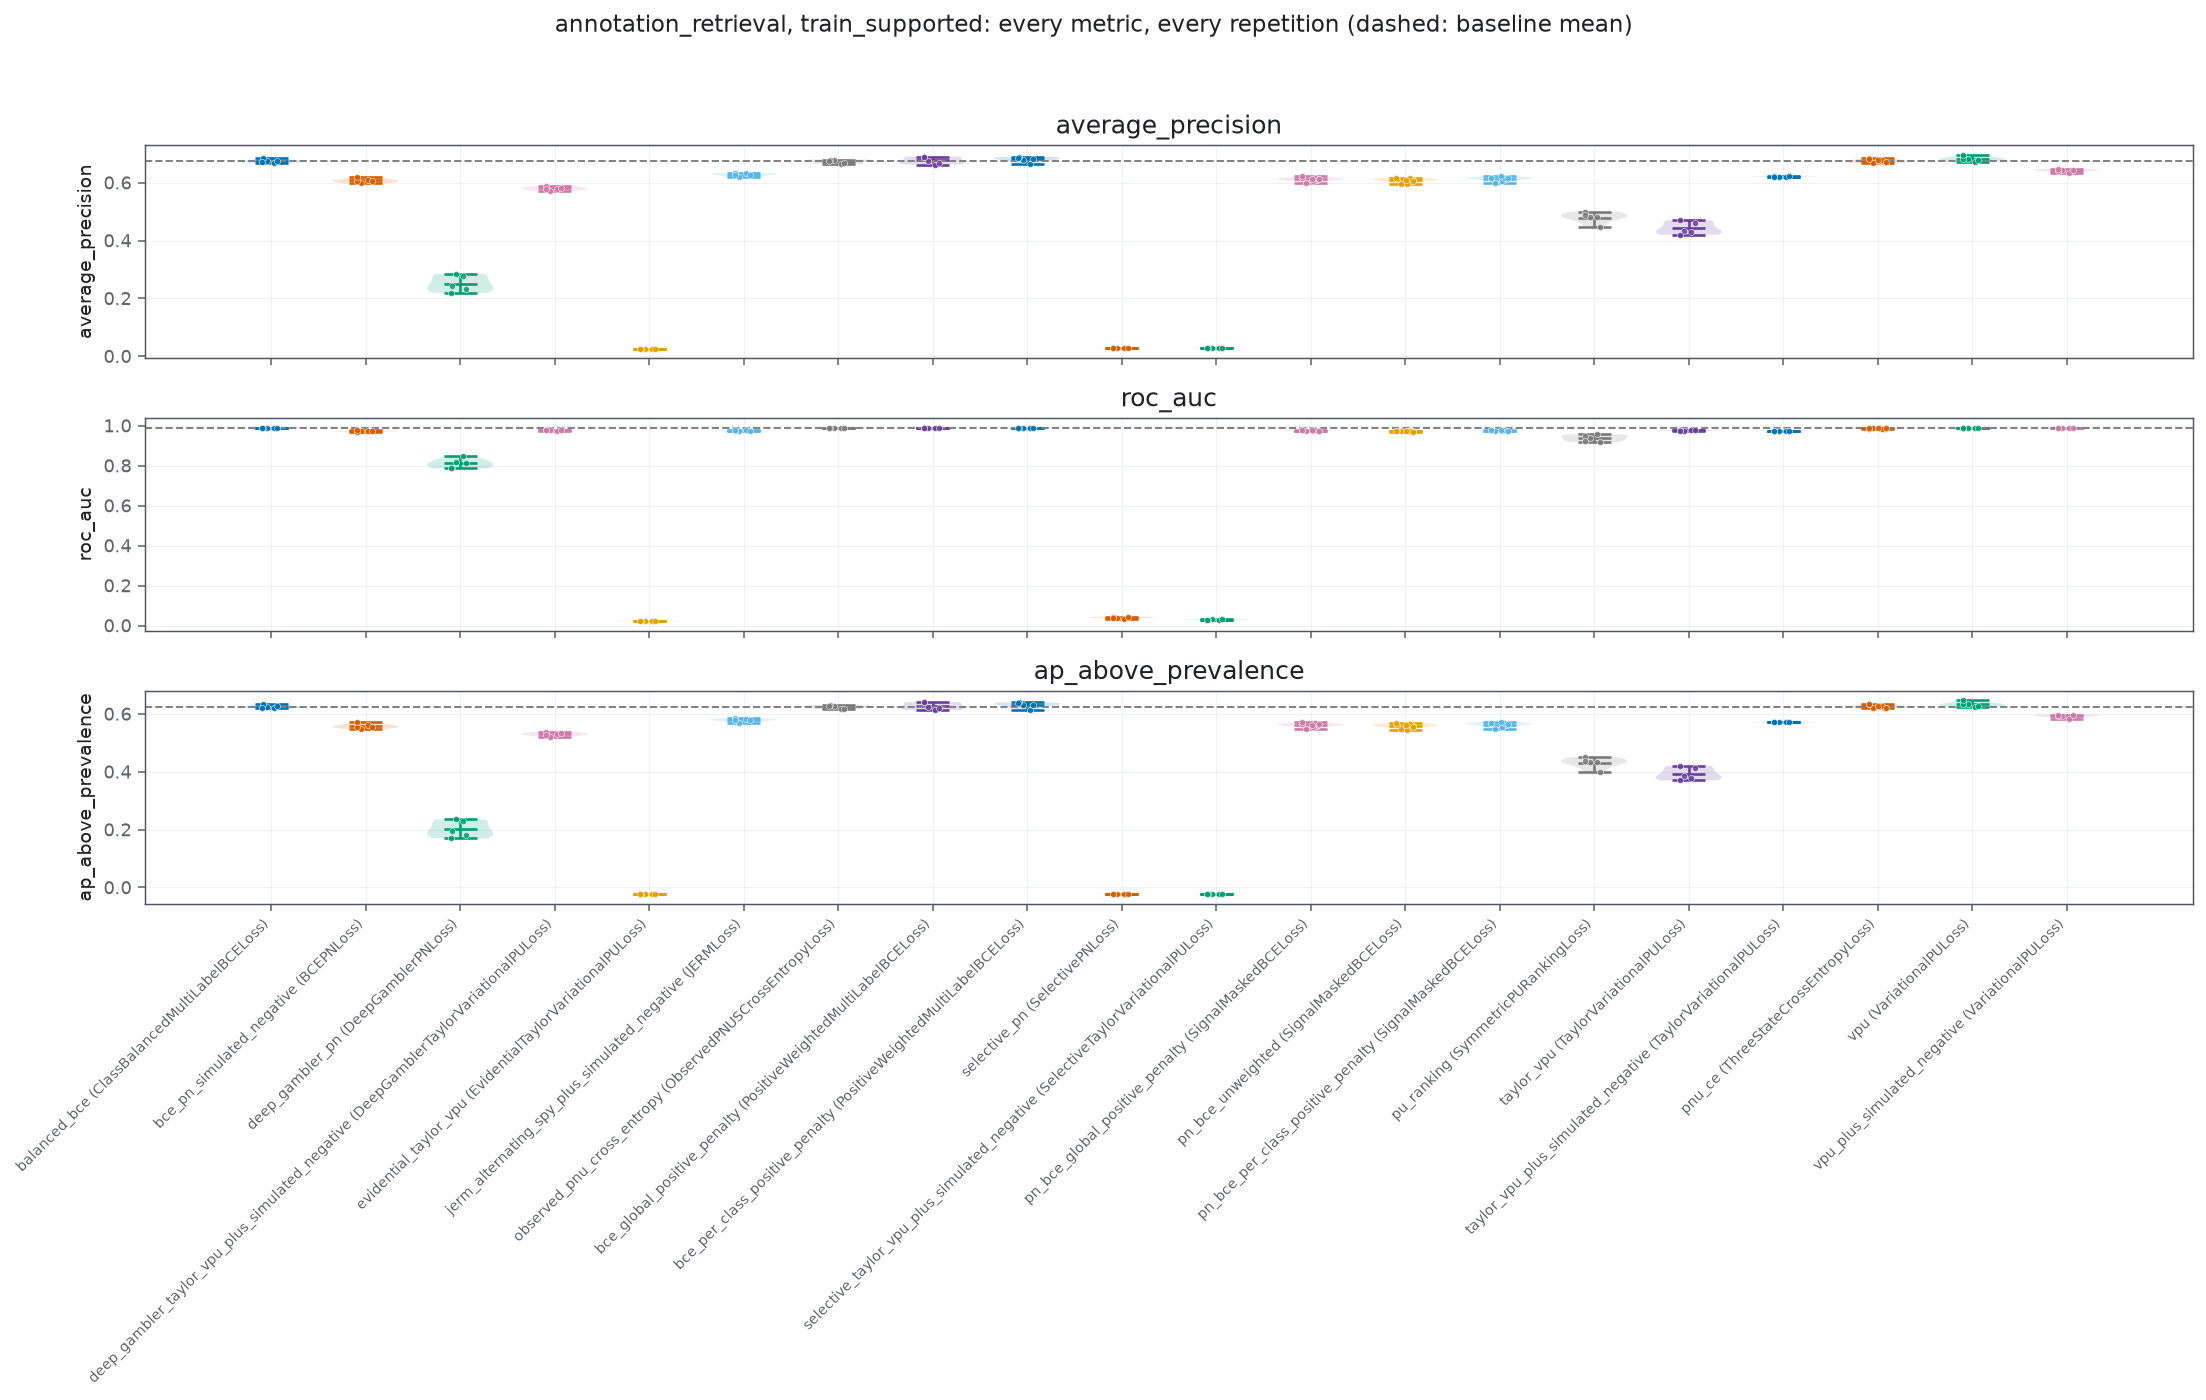

In [7]:
def metric_samples(metric, *, population=POPULATION, scope="train_supported", split=SPLIT):
    selected = prediction.query("metric == @metric and population == @population and scope == @scope and split == @split")
    return {label: group["value"].to_numpy() for label, group in selected.groupby("label")}

baseline_label = ready.query("role == 'baseline'").label.iloc[0]

figure, axes = plt.subplots(len(METRIC_ORDER), 1, figsize=(16, 10), dpi=theme.figure_dpi, sharex=True)
for axis, metric in zip(np.atleast_1d(axes), METRIC_ORDER):
    samples = metric_samples(metric)
    for position, label in enumerate(CONDITION_ORDER):
        values = samples.get(label)
        if values is None or not len(values):
            continue
        plot_violin_with_points(values, position=position, ax=axis, width=0.7, color=LABEL_COLOR[label], point_size=10.0, jitter=0.10, theme=theme)
    if baseline_label in samples:
        axis.axhline(float(np.mean(samples[baseline_label])), color="grey", linestyle="--", linewidth=1)
    axis.set_xticks(range(len(CONDITION_ORDER)))
    axis.set(ylabel=metric, title=metric)
    axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
for axis in np.atleast_1d(axes)[:-1]:
    axis.tick_params(axis="x", labelbottom=False)
np.atleast_1d(axes)[-1].set_xticklabels(CONDITION_ORDER, rotation=45, ha="right", fontsize=7)
figure.suptitle(f"{POPULATION}, train_supported: every metric, every repetition (dashed: baseline mean)", y=0.995, fontsize=12)
figure.tight_layout(rect=(0, 0, 1, 0.97))

## Generalization gap between the training and evaluation split

### Methodology

#### Theoretical

The gap $\mathrm{AP}^{\mathrm{train}}_c-\mathrm{AP}^{\mathrm{test}}_c$ tells whether a
condition merely memorizes the training annotations. Because a positive-weighting scheme
directly targets the training class balance, a gap difference here is informative in a way
it would not be for a plain reconstruction objective.

#### Implementation

The gap is computed per repetition, pairing each run's own training and evaluation
values, then shown as a distribution across repetitions.

#### Figure descriptions

Left: per condition, the distribution over repetitions of the paired train-minus-test
average precision gap; zero means identical performance on both splits. Right: the two
absolute levels per condition (mean over repetitions), training as open markers,
evaluation as filled markers, connected per condition.

### Remarks

### Notes

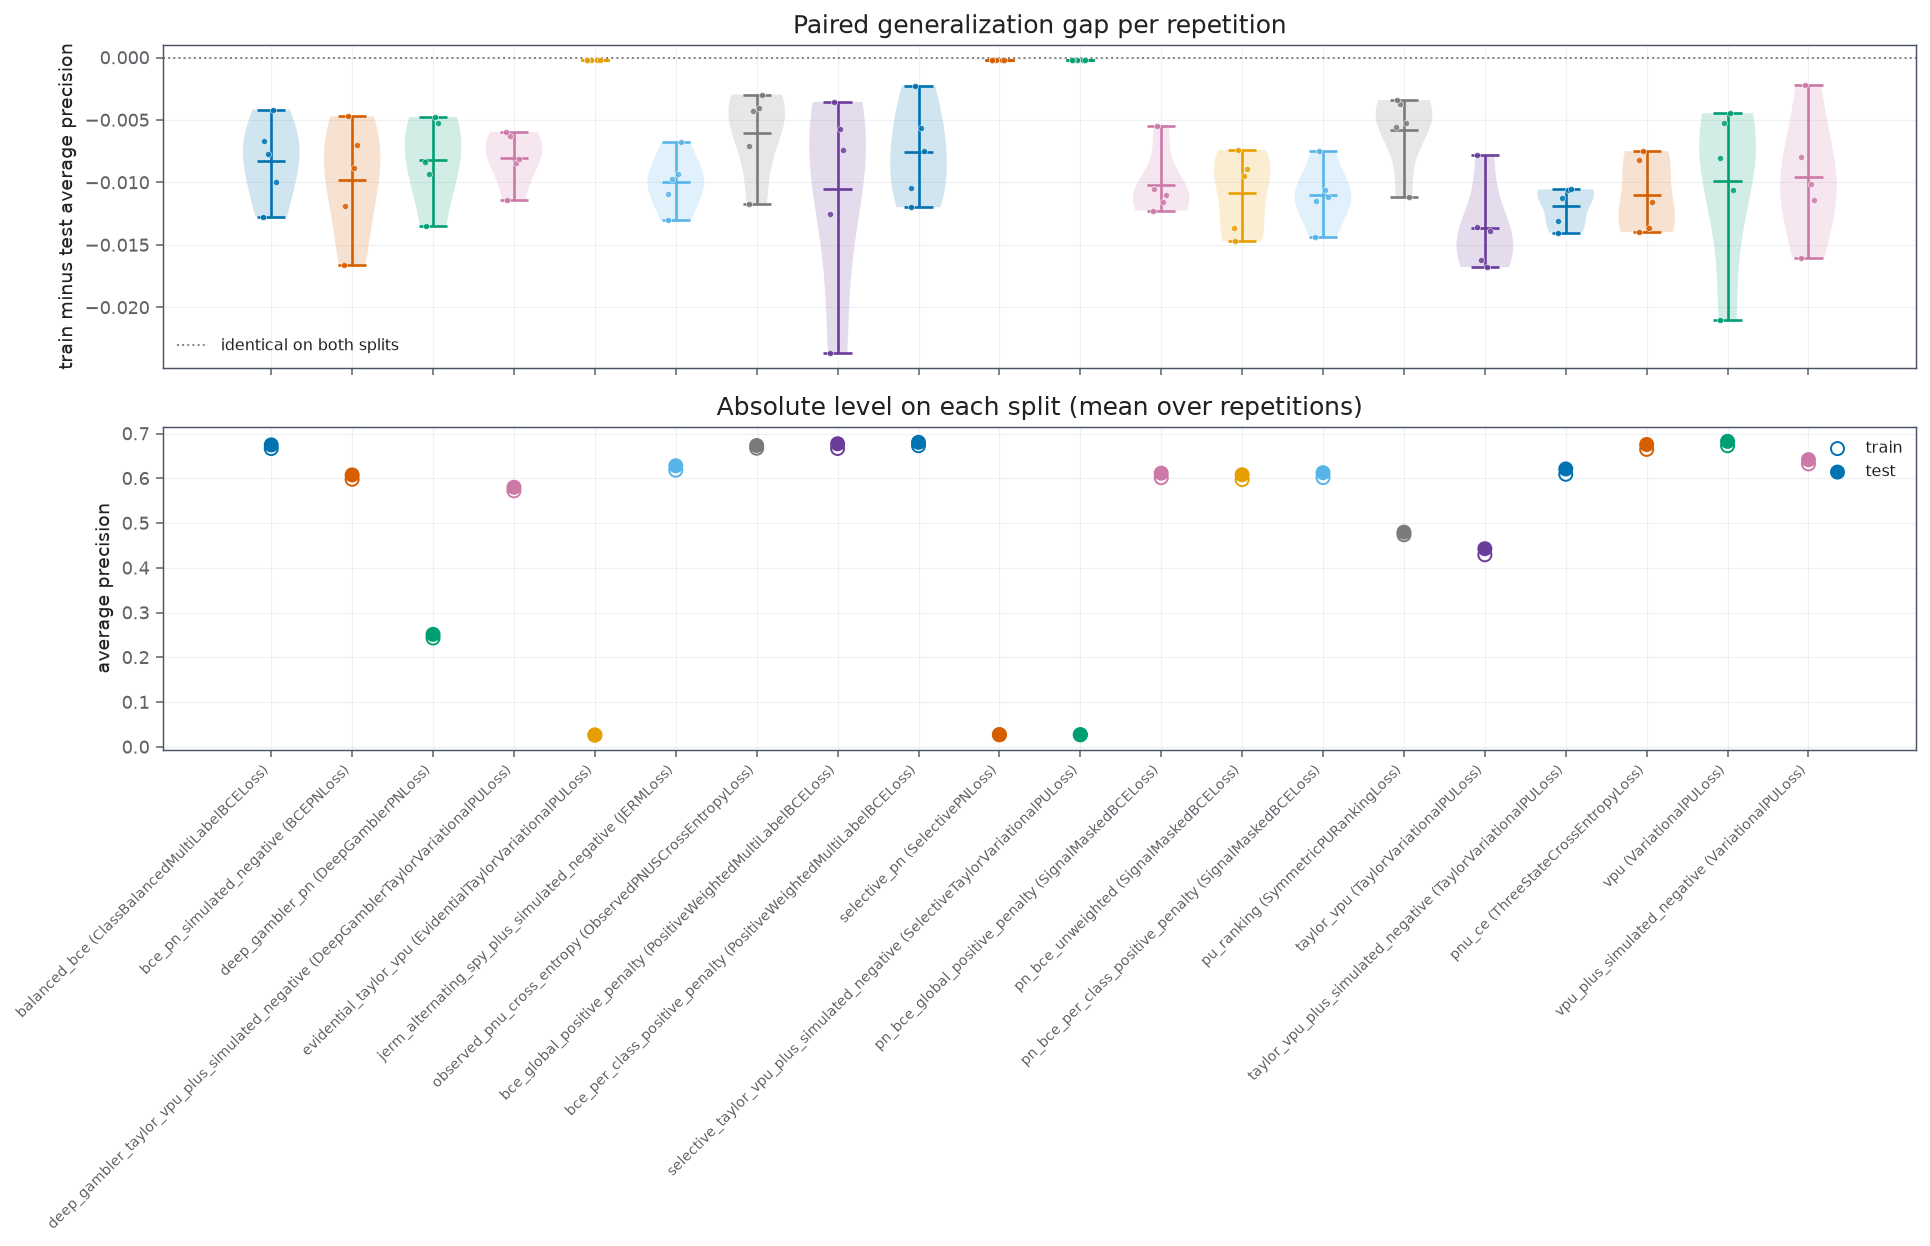

In [8]:
paired = (
    prediction.query("population == @POPULATION and scope == 'train_supported' and metric == 'average_precision'")
    .pivot_table(index=["label", "repetition"], columns="split", values="value")
    .dropna(subset=["train", "test"])
)
paired["gap"] = paired["train"] - paired["test"]

figure, (gap_axis, level_axis) = plt.subplots(2, 1, figsize=(14.0, 9.0), dpi=theme.figure_dpi, sharex=True)

for position, label in enumerate(CONDITION_ORDER):
    if label not in paired.index.get_level_values("label"):
        continue
    plot_violin_with_points(paired.loc[label, "gap"].to_numpy(), position=position, ax=gap_axis, width=0.7, color=LABEL_COLOR[label], point_size=10.0, jitter=0.10, theme=theme)
gap_axis.axhline(0.0, color="grey", linestyle=":", linewidth=1, label="identical on both splits")
gap_axis.set_xticks(range(len(CONDITION_ORDER)))
gap_axis.tick_params(axis="x", labelbottom=False)
gap_axis.set(ylabel="train minus test average precision", title="Paired generalization gap per repetition")
gap_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
gap_axis.legend(fontsize=8, frameon=theme.legend_frame)

levels = paired.groupby("label")[["train", "test"]].mean().reindex(CONDITION_ORDER).dropna()
positions = [CONDITION_ORDER.index(label) for label in levels.index]
for position, (label, row) in zip(positions, levels.iterrows()):
    level_axis.plot([position, position], [row["train"], row["test"]], color=LABEL_COLOR[label], alpha=0.5, linewidth=1)
level_axis.scatter(positions, levels["train"], facecolors="none", edgecolors=[LABEL_COLOR[l] for l in levels.index], s=45, label="train")
level_axis.scatter(positions, levels["test"], color=[LABEL_COLOR[l] for l in levels.index], s=45, label="test")
level_axis.set_xticks(range(len(CONDITION_ORDER)))
level_axis.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right", fontsize=7)
level_axis.set(ylabel="average precision", title="Absolute level on each split (mean over repetitions)")
level_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
level_axis.legend(fontsize=8, frameon=theme.legend_frame)

figure.tight_layout()

## Class-frequency dependence

### Methodology

#### Theoretical

A macro average weights every class equally regardless of how many training positives
it had. Plotting per-class validation average precision against the class's own
training positive count shows whether a condition's quality is uniform across the
frequency spectrum or concentrated on classes that were already well supported.

#### Implementation

One point per (condition, class) pair, from the base `per_class` table on the
validation split, population `annotation_retrieval`, eligible classes only.

#### Figure descriptions

x-axis: training positive count for the class (log). y-axis: validation average
precision for that class under that condition. Colour: condition. A flat cloud at low
counts means the condition is not exploiting scarce classes any better than chance; a
rising trend at low counts (relative to another condition) is a rare-class advantage.

### Remarks

### Notes

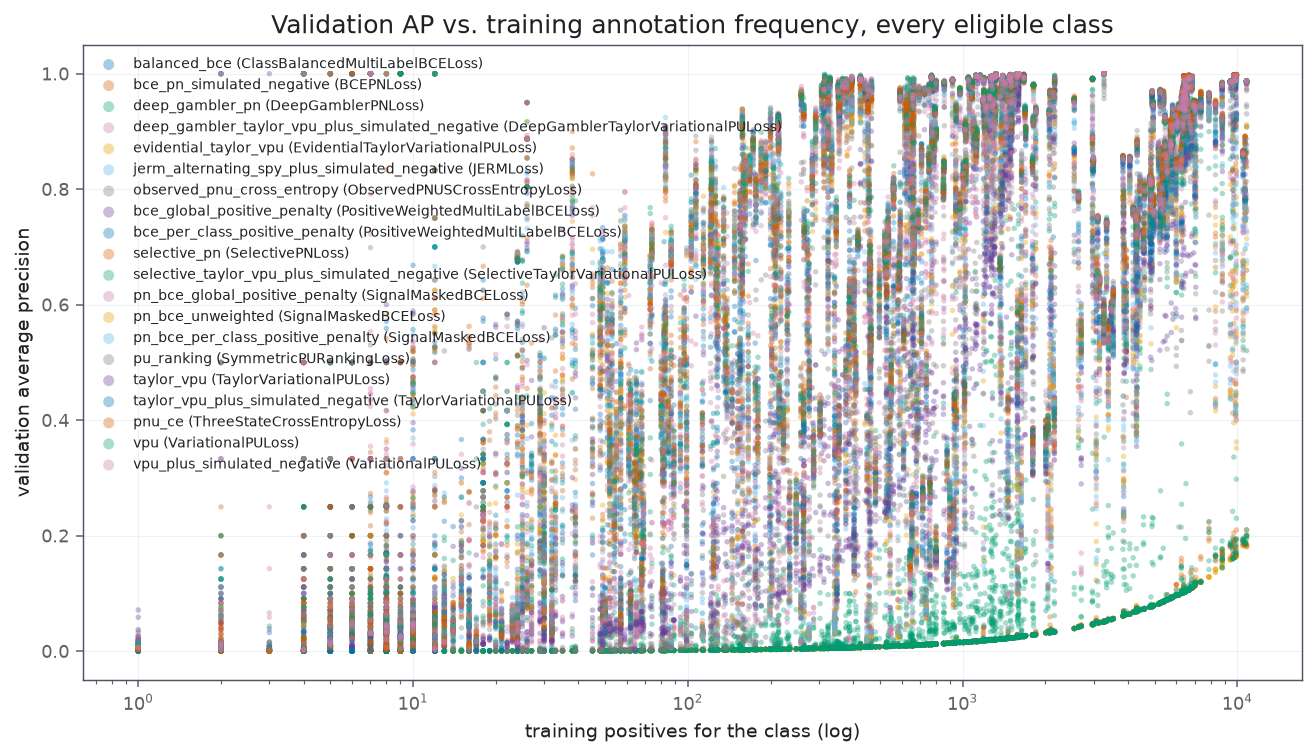

In [13]:
frequency_dependence = per_class.query("split == 'validation' and population == @POPULATION and eligible")

figure, axis = plt.subplots(figsize=(9.5, 5.5), dpi=theme.figure_dpi)
for label in CONDITION_ORDER:
    subset = frequency_dependence.query("label == @label")
    axis.scatter(subset["train_positives"], subset["average_precision"], s=8, alpha=0.35,
                color=LABEL_COLOR[label], edgecolor="none", label=label)
axis.set_xscale("log")
axis.set(xlabel="training positives for the class (log)", ylabel="validation average precision",
        title="Validation AP vs. training annotation frequency, every eligible class")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
axis.legend(fontsize=7, frameon=theme.legend_frame, markerscale=2)
figure.tight_layout()

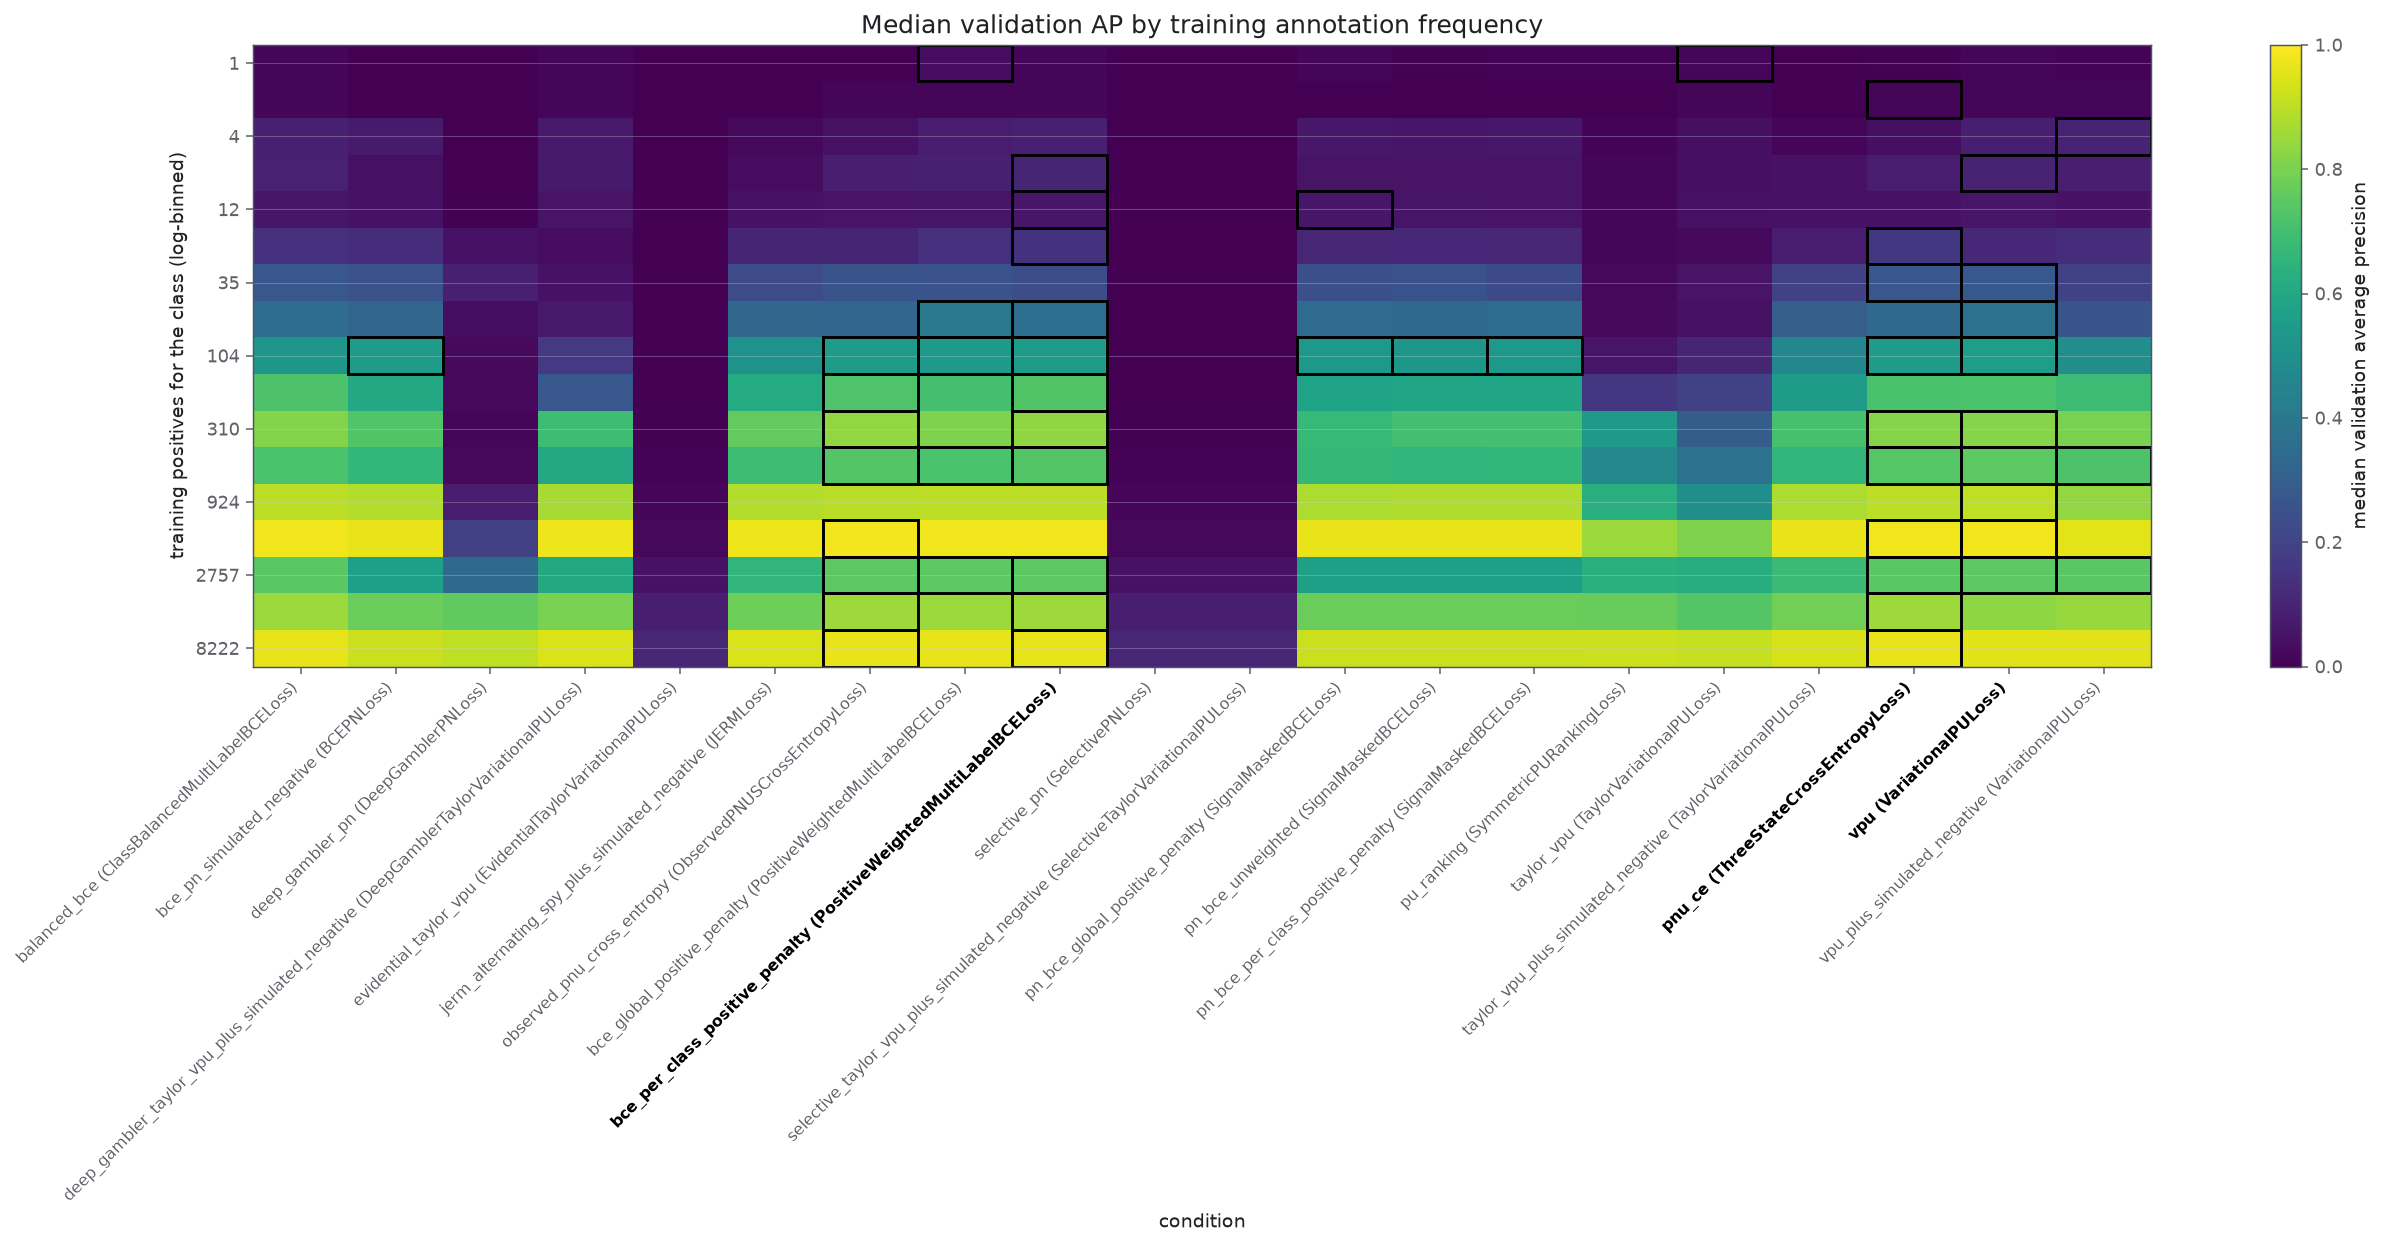

In [ ]:
frequency_dependence = per_class.query("split == 'validation' and population == @POPULATION and eligible").copy()

bins = np.logspace(
    np.log10(frequency_dependence["train_positives"].min()),
    np.log10(frequency_dependence["train_positives"].max()),
    18,
)
frequency_dependence["frequency_bin"] = pd.cut(
    frequency_dependence["train_positives"],
    bins=bins,
    include_lowest=True,
)
frequency_summary = (
    frequency_dependence.groupby(["label", "frequency_bin"], observed=True)["average_precision"]
    .median()
    .unstack()
    .reindex(CONDITION_ORDER)
)

baseline_values = frequency_summary.loc[baseline_label]
better_than_baseline = frequency_summary.gt(baseline_values, axis=1)
fraction_better = better_than_baseline.mean(axis=1)

figure, axis = plt.subplots(figsize=(0.75 * len(CONDITION_ORDER) + 4.0, 9.0), dpi=theme.figure_dpi)
image = axis.imshow(
    frequency_summary.T.to_numpy(),
    aspect="auto",
    interpolation="nearest",
    vmin=0,
    vmax=1,
)
for x, label in enumerate(CONDITION_ORDER):
    for y, better in enumerate(better_than_baseline.loc[label]):
        if better:
            axis.add_patch(
                plt.Rectangle(
                    (x - 0.5, y - 0.5),
                    1,
                    1,
                    fill=False,
                    edgecolor="black",
                    linewidth=1.5,
                )
            )
axis.set_xticks(range(len(CONDITION_ORDER)))
axis.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right", fontsize=8)
for tick, label in zip(axis.get_xticklabels(), CONDITION_ORDER):
    if fraction_better.loc[label] > 0.5:
        tick.set_fontweight("bold")
        tick.set_color("black")

centers = np.sqrt(bins[:-1] * bins[1:])
shown = np.arange(0, len(centers), 2)
axis.set_yticks(shown)
axis.set_yticklabels([f"{centers[i]:.0f}" for i in shown])
axis.set(
    xlabel="condition",
    ylabel="training positives for the class (log-binned)",
    title="Median validation AP by training annotation frequency",
)
colorbar = figure.colorbar(image, ax=axis)
colorbar.set_label("median validation average precision")
figure.tight_layout()

## Per-class average precision

### Methodology

#### Theoretical

A macro average over several hundred classes is one number over a heterogeneous
population. The per-class distribution shows whether a condition helps broadly or
trades some classes against others.

#### Implementation

Per-class records come from the base `per_class` table, evaluation split, population
`annotation_retrieval`, eligible classes only, pooled over repetitions.

#### Figure descriptions

Left: per condition, the distribution of per-class average precision (violin: every
eligible class; points: a fixed-size random subsample, since several hundred points per
violin is unreadable). Right: for the baseline and the best/worst condition by macro
average precision, each class's training positive count (log) against its average
precision.

### Remarks

### Notes

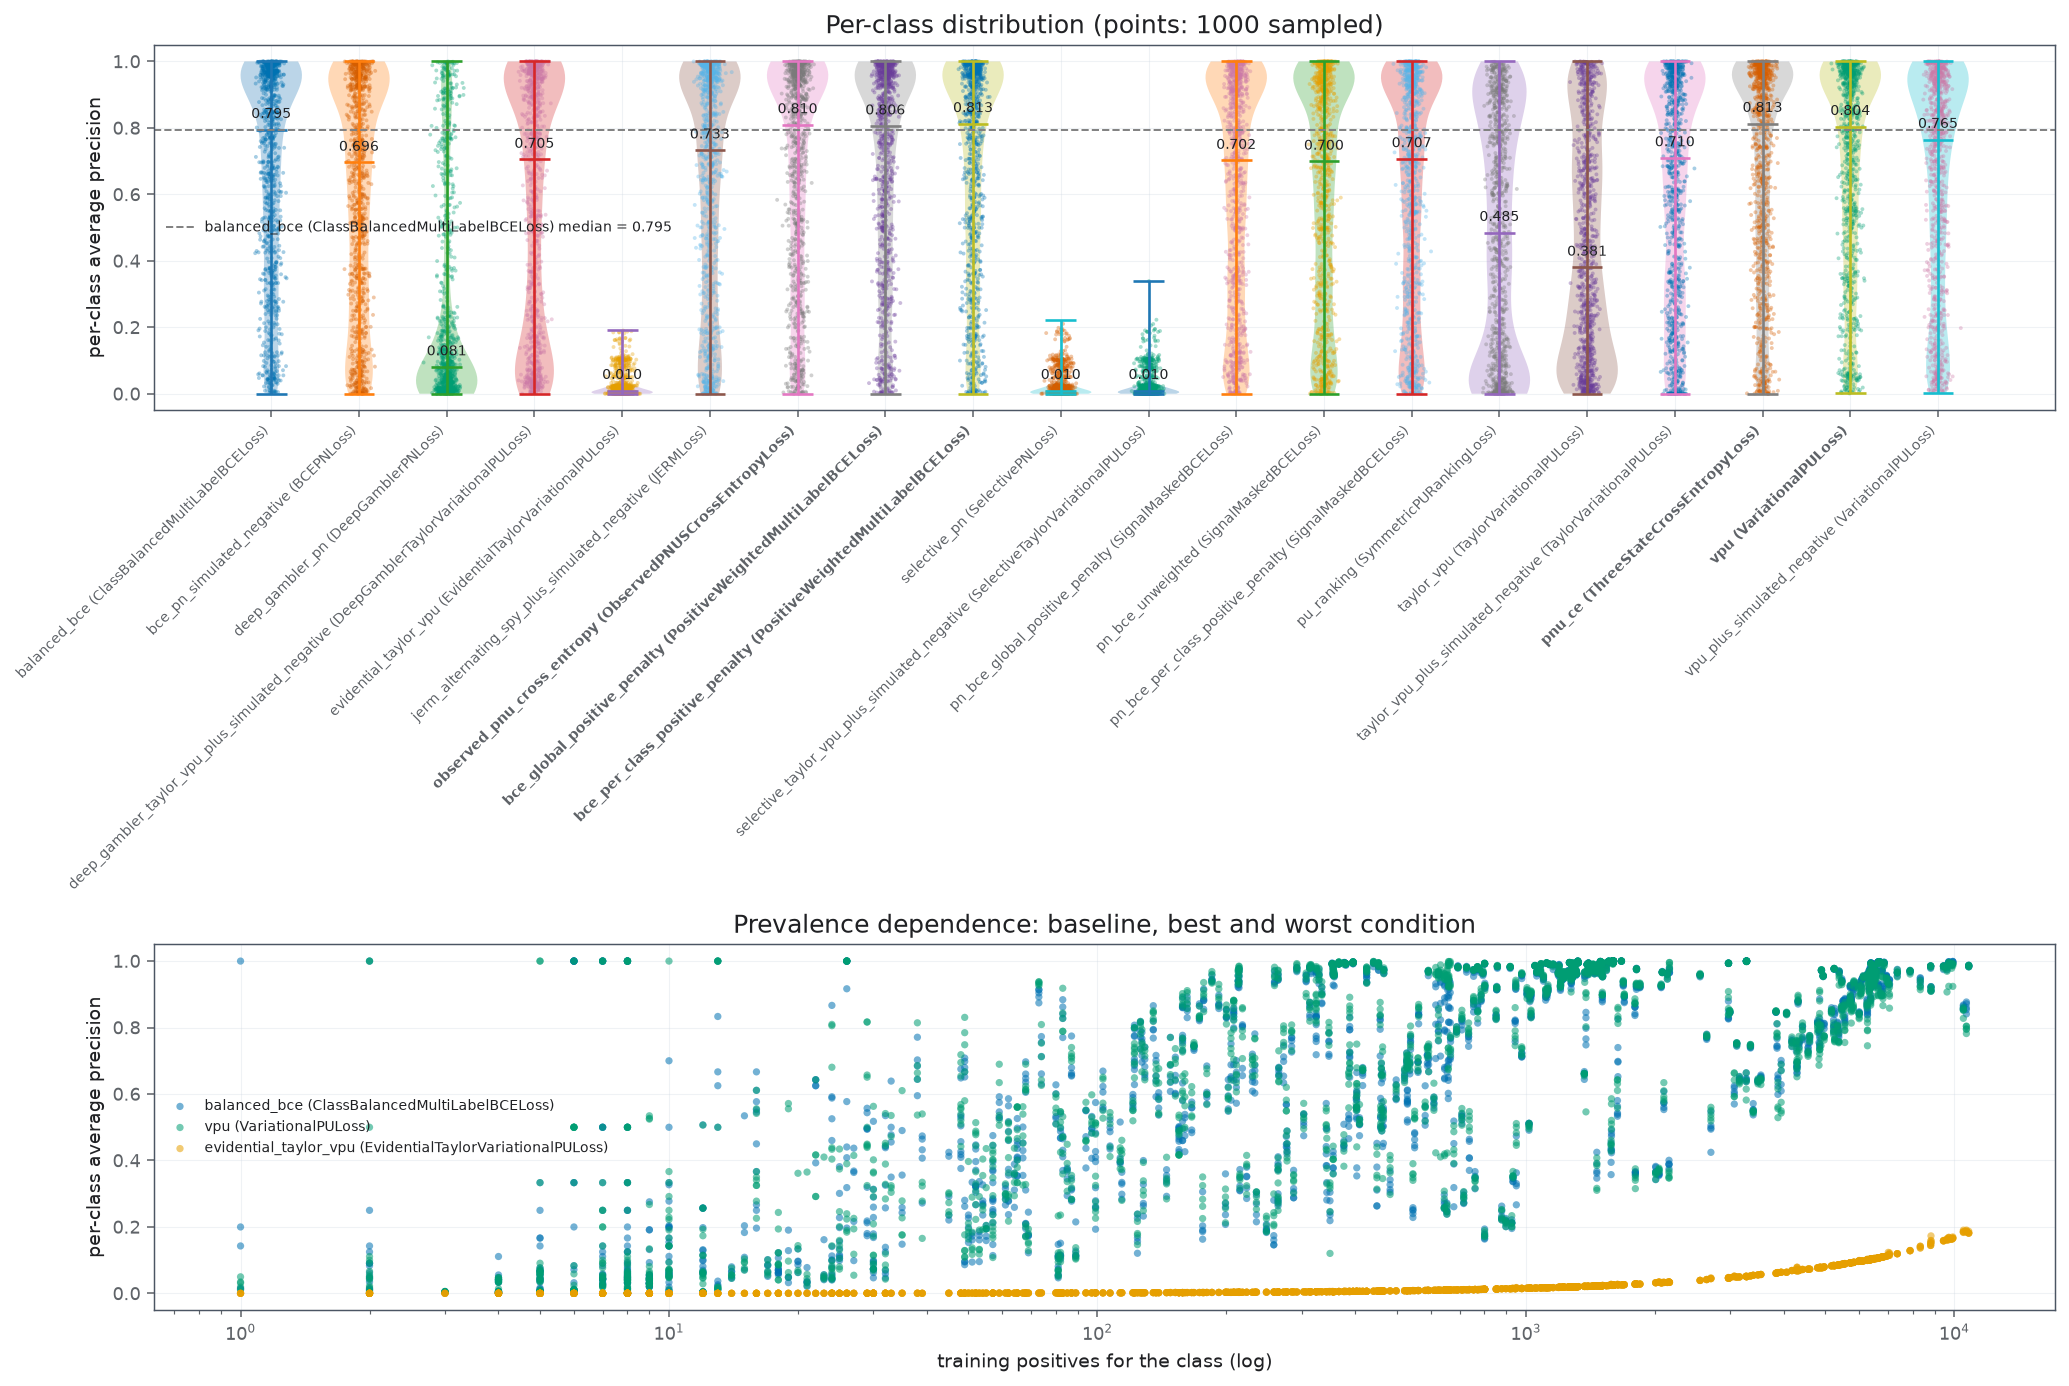

In [14]:
PER_CLASS_POINT_SAMPLE = 1_000

point_rng = np.random.default_rng(SAMPLE_SEED)
eligible_test = per_class.query("split == @SPLIT and population == @POPULATION and eligible")

median_by_label = eligible_test.groupby("label")["average_precision"].median()
baseline_median = median_by_label[baseline_label]

figure, (distribution_axis, prevalence_axis) = plt.subplots(2, 1, figsize=(15.0, 10.0), dpi=theme.figure_dpi)

for position, label in enumerate(CONDITION_ORDER):
    values = eligible_test.query("label == @label")["average_precision"].dropna().to_numpy()
    if not len(values):
        continue
    shown = values if len(values) <= PER_CLASS_POINT_SAMPLE else point_rng.choice(values, PER_CLASS_POINT_SAMPLE, replace=False)
    distribution_axis.violinplot([values], positions=[position], widths=0.7, showmeans=False, showmedians=True)
    distribution_axis.scatter(position + point_rng.normal(0.0, 0.06, size=len(shown)), shown, color=LABEL_COLOR[label], s=4, alpha=0.35, edgecolor="none")
    distribution_axis.text(position, np.median(values) + 0.025, f"{np.median(values):.3f}", ha="center", va="bottom", fontsize=7)

distribution_axis.axhline(baseline_median, color="grey", linestyle="--", linewidth=1, label=f"{baseline_label} median = {baseline_median:.3f}")
distribution_axis.set_xticks(range(len(CONDITION_ORDER)))
distribution_axis.set_xticklabels(CONDITION_ORDER, rotation=45, ha="right", fontsize=7)

for tick, label in zip(distribution_axis.get_xticklabels(), CONDITION_ORDER):
    if label in median_by_label and median_by_label[label] > baseline_median:
        tick.set_fontweight("bold")

distribution_axis.set(ylabel="per-class average precision", title=f"Per-class distribution (points: {PER_CLASS_POINT_SAMPLE} sampled)")
distribution_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
distribution_axis.legend(fontsize=7, frameon=theme.legend_frame)

macro_ranking = summary_table["average_precision"].dropna().sort_values()
highlight = [baseline_label, macro_ranking.index[-1], macro_ranking.index[0]]

for label in dict.fromkeys(highlight):
    subset = eligible_test.query("label == @label")
    prevalence_axis.scatter(subset["train_positives"], subset["average_precision"], color=LABEL_COLOR.get(label, "grey"), s=14, alpha=0.55, edgecolor="none", label=label)

prevalence_axis.set_xscale("log")
prevalence_axis.set(xlabel="training positives for the class (log)", ylabel="per-class average precision", title="Prevalence dependence: baseline, best and worst condition")
prevalence_axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
prevalence_axis.legend(fontsize=7, frameon=theme.legend_frame)

figure.tight_layout()

## Contrast against the baseline

### Methodology

#### Theoretical

Repetition $r$ of any two conditions shares its split and data-loader seeds and differs
only in initialization/training seeds, so the comparison should be paired. A condition
is called separated from the baseline when its interval excludes zero; with 8 swept
conditions against one baseline and no multiple-comparison correction, a single
near-boundary condition is weak evidence.

#### Implementation

`experimental_units`/`paired_comparisons`/`baseline_contrasts` (shared with `part_3`'s
own baseline-contrast section) applied to `average_precision`, population
`annotation_retrieval`, scope `train_supported`, evaluation split.

#### Figure descriptions

Table: one row per condition, the mean paired difference in average precision against
the baseline and its 95% across-seed interval. Figure: the same as an error-bar plot,
black-edged markers where the interval excludes zero.

### Remarks

### Notes

2026-09-14 15:20:45,499 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:194 | Oriented 35 baseline contrasts as candidate minus reference.


,label,pairs,mean_difference,ci_low,ci_high
12,bce_global_positive_penalty (PositiveWeightedM...,5,0.0026,-0.0115,0.0166
15,pnu_ce (ThreeStateCrossEntropyLoss),5,0.0009,-0.0070,0.0088
18,pu_ranking (SymmetricPURankingLoss),5,-0.1950,-0.2187,-0.1713
21,pn_bce_global_positive_penalty (SignalMaskedBC...,5,-0.0631,-0.0727,-0.0535
24,pn_bce_unweighted (SignalMaskedBCELoss),5,-0.0667,-0.0784,-0.0550
27,vpu (VariationalPULoss),5,0.0079,-0.0056,0.0214
30,pn_bce_per_class_positive_penalty (SignalMaske...,5,-0.0621,-0.0724,-0.0517
33,bce_per_class_positive_penalty (PositiveWeight...,5,0.0057,-0.0041,0.0155


2026-09-14 15:20:45,560 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.predictive_reports:336 | Saved 1 analytical tables in assets/experiments/autoencoder_architecture/notebooks/14_09_predictive_expanded/part_4_prediction_global_results.


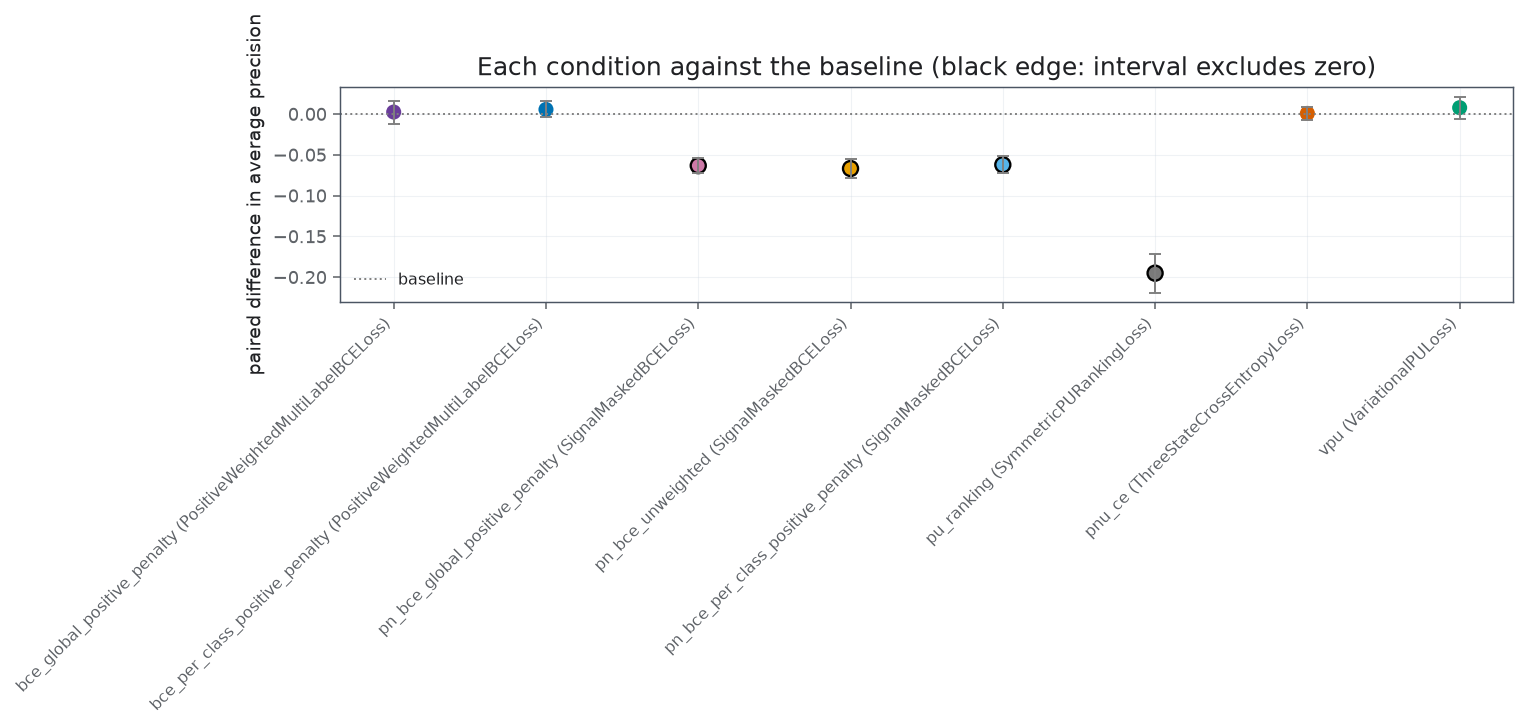

In [9]:
# `groups` must name at least one measurement key (paired_comparisons groups its
# per-pair differences by it); "metric" is used even though the display below narrows
# to `average_precision`, so the same call also yields roc_auc/ap_above_prevalence
# contrasts for free, written out below.
contrast_source = prediction.query("split == @SPLIT and population == @POPULATION and scope == 'train_supported' and metric in @METRIC_ORDER")
units = reports.experimental_units(contrast_source, ready, ["metric"])
_, contrasts = reports.paired_comparisons(units, ["metric"])
baseline_contrasts = reports.baseline_contrasts(contrasts, ready)
display(baseline_contrasts.query("metric == 'average_precision'")[["label", "pairs", "mean_difference", "ci_low", "ci_high"]].round(4))

ap_contrasts = baseline_contrasts.query("metric == 'average_precision'")
plotted = ap_contrasts.dropna(subset=["mean_difference"]).set_index("label").reindex(
    [label for label in CONDITION_ORDER if label in ap_contrasts.label.values])
positions = np.arange(len(plotted))
figure, axis = plt.subplots(figsize=(11.0, 5.0), dpi=theme.figure_dpi)
axis.errorbar(positions, plotted["mean_difference"],
             yerr=[plotted["mean_difference"] - plotted["ci_low"], plotted["ci_high"] - plotted["mean_difference"]],
             fmt="none", ecolor="grey", elinewidth=1, capsize=3)
axis.scatter(positions, plotted["mean_difference"], s=60, color=[LABEL_COLOR[l] for l in plotted.index],
            edgecolor=["black" if ci_low > 0 or ci_high < 0 else "none"
                       for ci_low, ci_high in zip(plotted["ci_low"], plotted["ci_high"])], linewidth=1.2)
axis.axhline(0.0, color="grey", linestyle=":", linewidth=1, label="baseline")
axis.set_xticks(positions)
axis.set_xticklabels(plotted.index, rotation=45, ha="right", fontsize=8)
axis.set(ylabel="paired difference in average precision", title="Each condition against the baseline (black edge: interval excludes zero)")
axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
axis.legend(fontsize=8, frameon=theme.legend_frame)
figure.tight_layout()

reports.save_tables(RESULTS, baseline_contrasts=baseline_contrasts)

## Reproducible artifacts

### Methodology

#### Implementation

The measured tables and their provenance are written by the base precompute runner, not
here; this notebook adds only `baseline_contrasts.csv`, a cheap derived aggregation of
tables already in memory.

The results directory is deliberately not versioned: it is regenerable.

### Remarks

### Notes

In [10]:
print("derived tables written:", sorted(path.name for path in RESULTS.glob("*.csv")))

derived tables written: ['baseline_contrasts.csv']


## Results / Summary

### LLM

Not yet run against the real campaign cache. This notebook has not been executed
against `data/kidney_workspace`; run the base inference cache, then write this section
from the actually observed metrics, generalization gaps, class-frequency dependence and
baseline contrasts before treating any interpretation here as verified.

### Person